In [3]:
import os
import sys
import numba
import numpy as np
import pandas as pd

sys.path.append("../..")

from strategy.data.utils import load
from strategy.indicator.common import TR
from strategy.indicator.common import MA
from strategy.indicator.common import ATR
from strategy.common.constant import DAY_MS_COUNT

In [4]:
# df = pd.read_csv('../../data/DOGEUSD_PERP_renko_0.001.csv')
raw = load('BTCUSD_PERP', '../../../data').reset_index(drop=True)

In [5]:
period = 8 * 3600000 # 8 hours # DAY_MS_COUNT
k, short, long = 0.618, 20, 150 
df = raw#.iloc[-1440*90:].copy()
# df = df.reset_index(drop=True)
df['gid'] = df.start_t // period
gdf = df.groupby('gid').agg({
    'gid': 'first',
    'open':'first', 'high':'max', 'low':'min', 'close':'last'}
)
atr = ATR(short).calc(gdf).to_frame('atr').shift(1)
atr['ma'] = MA(short).calc(gdf).to_frame('ma').shift(1)
atr['gid'] = gdf.gid
df = df.join(atr, on='gid', rsuffix='_x')
df = df.dropna()
print(df.shape)

(608160, 16)


In [49]:
# 固定百分比，止盈/止损 with ATR
# @numba.jit(nopython=True)
def forward(data, s1, s2, mp, enpp, atr_t, start):
    for i in range(start, data.shape[0] - 1):
        t, o, h, l, c, atr = data[i,0], data[i,1], data[i,2], data[i,3], \
            data[i,4], data[i,5]
        pos = i + 1
        nt, no, nh, nl, nc, natr = data[pos,0], data[pos,1], data[pos,2], data[pos,3], \
            data[pos,4], data[i, 5]
        # long  
        spp = round(enpp - s1 * atr_t, 5)
        if mp > 0 and nl <= spp: # 止损
            return 'A', pos, spp
        spp = round(enpp + s2 * atr_t, 5)
        if mp > 0 and nh >= spp: # 止盈
            return 'B', pos, spp
        # short
        spp = round(enpp + s1 * atr_t, 5)
        if mp < 0 and nh >= spp: # 止损
            return 'C', pos, spp
        spp = round(enpp - s2 * atr_t, 5)
        if mp < 0 and nl <= spp: # 止盈
            return 'D', pos, spp
    return 'E', -1, 0


# @numba.jit(nopython=True)
def train(data, length, k1, s1, s2, table, fee=0.0002):
    i, stat, total = 0, '', 0
    hist = 0
    while i < data.shape[0] - 1:
        t, o, h, l, c, atr = data[i,0], data[i,1], data[i,2], data[i,3], \
            data[i,4], data[i,5]
        pos = i + 1
        nt, no, nh, nl, nc, natr = data[pos,0], data[pos,1], data[pos,2], data[pos,3], \
            data[pos,4], data[i, 5] 
        if atr > 0:
            # best_stat, best_profit, best_k = (stat + 'F')[-length:], 0, pos
            n_profit = 0
            min_k, n_status = data.shape[0], (stat + 'F')[-length:]
            for act in [-1, 1]:
                a, k, p = forward(data, s1, s2, act, no, atr, i)
                n_stat = (stat + a)[-length:]
                profit = act * (p / no - 1.0) - fee
                if k < min_k:
                    min_k = k
                    n_status = n_stat
                    n_profit = profit
                elif n_profit < profit:
                    min_k = k
                    n_status = n_stat
                    n_profit = profit 
                # if best_profit < profit:
                #     best_profit = profit
                #     best_stat = n_stat
                #     best_k = k
                # if stat not in table:
                #     table[stat] = [0, 0, 0]
                # if n_stat in table:
                #     table[stat][act+1] = k1 * max(table[n_stat]) + profit
                # else:
                #     table[stat][act+1] = profit
            if stat not in table:
                table[stat] = [0, 0, 0]
            
            total += n_profit
            if min_k <= 0:
                print('total-profit', total)
                return table
            i = min_k
            stat = n_status
        else:
            i += 1
    print('profit', profit)
    return table

In [50]:
fields = ["start_t", "open", "high","low", "close", "atr"]

table, fee = {}, 0.0002
for i in range(1):
    print('+' * 32, i)
    train(df[fields].values, 5, 0.95, 0.3, 0.3, table, fee)

++++++++++++++++++++++++++++++++ 0
B 0 0.0019919709840152456
BB 0.0019919709840152456 0.001940559267507891
BBD 0.003932530251523137 0.0019538298548575695
BBDD 0.0058863601063807065 0.0019589253160746446
BBDDB 0.00784528542245535 0.0019631750685708883
BDDBB 0.009808460491026239 0.001958492346713059
DDBBB 0.011766952837739297 0.001953044174060259
DBBBB 0.013719997011799556 0.0019478125110050427
BBBBB 0.0156678095228046 0.0019430955825081365
BBBBB 0.017610905105312737 0.0019387617695016735
BBBBD 0.019549666874814412 0.0019731563112231677
BBBDB 0.02152282318603758 0.0019787332300586825
BBDBB 0.023501556416096265 0.0019736886307168745
BDBBB 0.02547524504681314 0.0019720291620288545
DBBBB 0.027447274208841996 0.0019687304339730317
BBBBD 0.02941600464281503 0.001963292432350805
BBBDB 0.03137929707516583 0.001968288837563592
BBDBD 0.033347585912729426 0.0019631166569935355
BDBDB 0.03531070256972296 0.0019680239660286648
DBDBB 0.03727872653575163 0.0020046496226972855
BDBBB 0.039283376158448916

In [36]:
len(table)

37

In [31]:
def rl(data, length, s1, s2, table):
    trans, mp, stat = [], 0, ''
    for i in range(0, data.shape[0] - 1):
        t, o, h, l, c, atr = data[i,0], data[i,1], data[i,2], data[i,3], \
            data[i,4], data[i,5]
        pos = i + 1
        nt, no, nh, nl, nc, natr = data[pos,0], data[pos,1], data[pos,2], data[pos,3], \
            data[pos,4], data[i, 5]
        if atr > 0:
            pass
        else:
            continue
        act = np.argmax(table[stat]) - 1
        if mp == 0 and act != 0:
            mp = act
            enpp = no
            entt = nt
            atr_t = atr
        # long  
        spp = round(enpp - s1 * atr_t, 5)
        if mp > 0 and nl <= spp: # 止损
            trans.append([mp, enpp, spp, entt, nt])
            stat = (stat + 'A')[-length:]
            mp = 0
        spp = round(enpp + s2 * atr_t, 5)
        if mp > 0 and nh >= spp: # 止盈
            trans.append([mp, enpp, spp, entt, nt])
            stat = (stat + 'B')[-length:]
            mp = 0
        # short
        spp = round(enpp + s1 * atr_t, 5)
        if mp < 0 and nh >= spp: # 止损
            trans.append([mp, enpp, spp, entt, nt])
            stat = (stat + 'C')[-length:]
            mp = 0
        spp = round(enpp - s2 * atr_t, 5)
        if mp < 0 and nl <= spp: # 止盈
            trans.append([mp, enpp, spp, entt, nt])
            stat = (stat + 'D')[-length:]
            mp = 0
        print('debug', enpp, stat)
    return trans

In [32]:
trans = rl(df[fields].values, 10, 0.3, 0.3, table)

debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 16928.6 
debug 1692

KeyError: 'BBDDBB'

In [11]:
def trans2pnl(trans, param, fee):
    if len(trans[0]) == 5:
        columns = ['pos', 'open', 'close', 'entt', 'close_t']
    elif len(trans[0]) == 7:
        columns = ['pos', 'open', 'close', 'entt', 'close_t', 'hpp', 'lpp']
    else:
        raise ValueError('trans.shape[1] not in (5,7)')
    rcd = pd.DataFrame(trans, columns=columns)
    profit = rcd.pos * (rcd.close - rcd.open)
    commis = rcd.pos.abs() * (rcd.close + rcd.open) * fee
    res = (profit - commis) / rcd.open
    win = (res > 0).sum()
    long_cnt = (rcd.pos > 0).sum()
    short_cnt = (rcd.pos < 0).sum()
    pnl = res.sum()
    s = 1 + res.cumsum()
    mdd = (s.expanding(min_periods=1).max() - s) / s
    mdd = mdd.max()
    if param:
        res.cumsum().plot(title=f"param:{param}, pnl={pnl:.4f})")
        res.index = rcd.entt
        return res, rcd, win/res.shape[0], res.shape[0], long_cnt, short_cnt
    return pnl, mdd, win/res.shape[0], res.shape[0], long_cnt, short_cnt

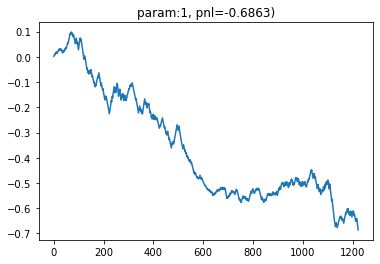

In [14]:
x = trans2pnl(trans, 1, 0)

In [17]:
x[1].pos.unique()

array([1])

In [92]:
# @numba.jit(nopython=True)
def gen_labels(prices, k1, s1):
    orders, hist = [], []
    unfilled, filled = set(), set()
    last_high = last_low = prices[0]
    for price in prices:
        new_brick = False
        lpp = (1 + k1) * last_high
        spp = (1 - k1) * last_low
        if price >= lpp:
            hist.append(price / last_high - 1.0)
            # print(price, last_low, last_high, hist[-1], price * k1)
            new_brick = True
            last_low = price / (1 + k1)
            last_high = price
        elif price <= spp:
            hist.append(price / last_low - 1.0)
            # print(price, last_low, last_high, hist[-1], price * k1)
            new_brick = True
            last_high = price / (1 - k1)
            last_low = price
        if new_brick:
            unfilled.add(len(orders))
            orders.append([price])
        new_trade = set()
        for oid in unfilled:
            order = orders[oid]
            lpp = order[0] * (1 + s1)
            spp = order[0] * (1 - s1)
            if price >= lpp:
                order.append(price)
                new_trade.add(oid)
            if price <= spp:
                order.append(price)
                new_trade.add(oid)
        filled |= new_trade
        unfilled -= new_trade
    return hist, orders, filled


# @numba.jit(nopython=True)
def gen_samples(hist, orders, filled, length):
    y, X = [], []
    assert len(hist) == len(orders)
    for oid in sorted(filled):
        if oid < length:
            continue
        order = orders[oid]
        y.append(order[1] / order[0] - 1.0)
        X.append(hist[oid-length:oid])
    return np.array(y), np.array(X)

In [4]:
from sklearn.linear_model import Lasso
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import confusion_matrix, f1_score

In [5]:
for k1 in [0.005]: # np.arange(0.001, 0.01, 0.002):
    for s1 in [0.005]: #np.arange(0.001, 0.01, 0.002):
        hist, orders, filled = gen_labels(raw.open.values, k1, s1)
        split_ratio = 0.8
        y, X = gen_samples(hist, orders, filled, 20)
        train_len = int(len(y) * split_ratio)
        train_y, train_X = y[:train_len], X[:train_len]
        valid_y, valid_X = y[train_len:], X[train_len:]
        # for alpha in np.arange(1, 10, 1):
        if True:
            # model = Lasso()
            model = LogisticRegressionCV()
            model.fit(train_X, train_y > 0)

            train_y1 = model.predict(train_X)
            print(
                "train:\n", confusion_matrix(np.array(train_y) > 0, np.array(train_y1) > 0))
            valid_y1 = model.predict(valid_X)
            y0 = np.array(valid_y) > 0
            y1 = np.array(valid_y1) > 0
            print("valid:", k1, s1, f1_score(y0, y1))

NameError: name 'gen_labels' is not defined

In [50]:
train_y1 = model.predict(train_X)
print(
    "train:\n", confusion_matrix(np.array(train_y) > 0, np.array(train_y1) > 0))
valid_y1 = model.predict(valid_X)
print(
    "valid:\n", confusion_matrix(np.array(valid_y) > 0, np.array(valid_y1) > 0))

train:
 [[ 410 1375]
 [ 395 1616]]
valid:
 [[132 268]
 [201 349]]
